# Get Tweet Data

## tweepy for API 1.0

要注意自己用的tweepy lib function是for 1.0 or 2.0，以下是Code fore 1.0。

In [5]:
# pip install tweepy

# API 1.0?

import tweepy

auth = tweepy.OAuth1UserHandler(
   consumer_key, consumer_secret, access_token, access_token_secret
)

api = tweepy.API(auth)

In [ ]:
public_tweets = api.home_timeline()
for tweet in public_tweets:
    print(tweet.text)
user = api.get_user(screen_name='adolfux')

## API 2.0

現在Twitter API2.0主要分成三種存取權限，通常剛註冊的人給的就是Essentials，學者有機會可以申請到Academic Research，可以獲得更多的Tweets。
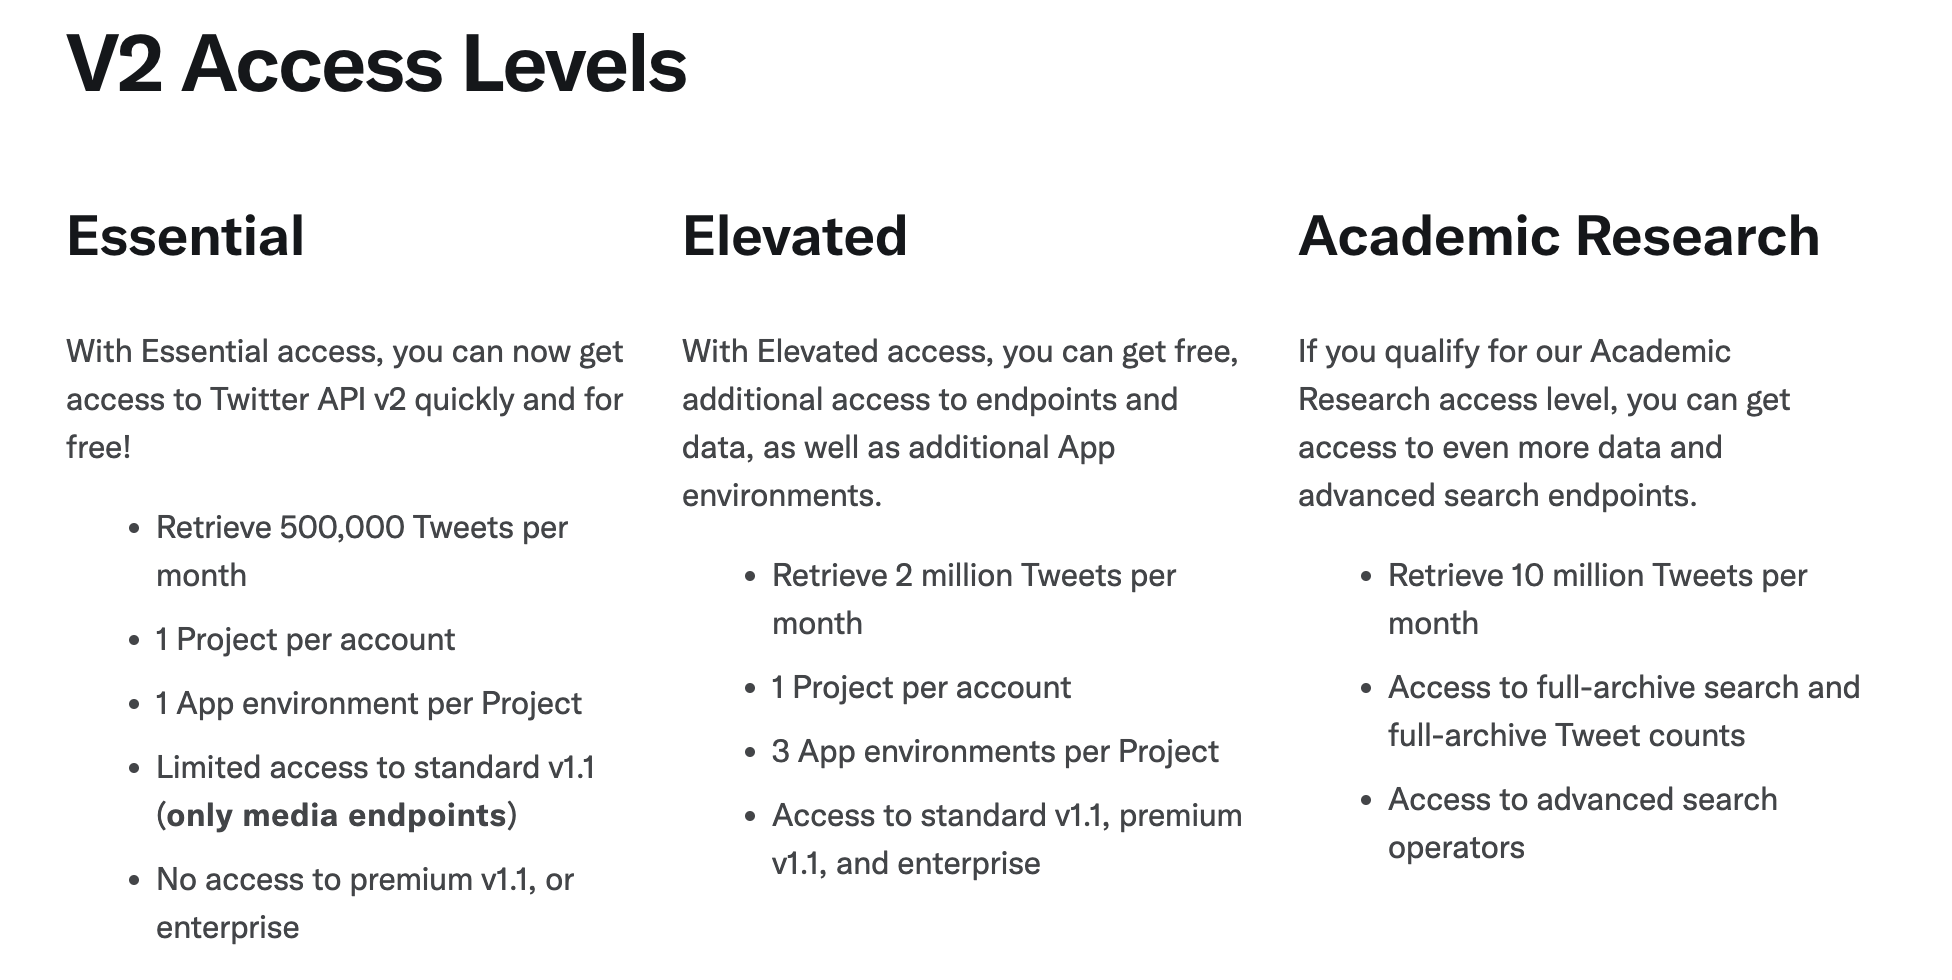

以下是搭配tweepy for Twitter API 2.0的函式操作結果

Possible option to avoid kick-out by twitter when meets limitation (Need to verify)
```
client = tweepy.Client( bearer_token=bearer_token, 
                        consumer_key=consumer_key, 
                        consumer_secret=consumer_secret, 
                        access_token=access_token, 
                        access_token_secret=access_token_secret, 
                        return_type = requests.Response,
                        wait_on_rate_limit=True)
```                       

In [10]:
import tweepy

bearer_token = "AAAAAAAAAAAAAAAAAAAAALXhhAEAAAAAL0PecvetxlytIdaoTYkkc5vZ14k%3Dh7EpA9gzwEieZQy5EqbOBvV3OuZ9epUEInYFL5O3FZGGsVmz8l"

client = tweepy.Client(bearer_token)
api = tweepy.API(client)

In [ ]:
# import tweepy

# bearer_token = None
# consumer_key = None
# # consumer_key = None
# consumer_secret = None
# # consumer_secret = None
# access_token = None
# access_token_secret = None

# client  = tweepy.Client(bearer_token=bearer_token, 
#                         consumer_key=consumer_key, 
#                         consumer_secret=consumer_secret, 
#                         access_token=access_token, 
#                         access_token_secret=access_token_secret)

* https://docs.tweepy.org/en/stable/client.html#tweepy.Client.search_all_tweets
* https://towardsdatascience.com/an-extensive-guide-to-collecting-tweets-from-twitter-api-v2-for-academic-research-using-python-3-518fcb71df2a
* Very Useful! https://dev.to/twitterdev/a-comprehensive-guide-for-using-the-twitter-api-v2-using-tweepy-in-python-15d9


Queries:
* `query = 'from:BarackObama -is:retweet'`

Fields: 
* https://developer.twitter.com/en/docs/twitter-api/fields

In [5]:
tweets = client.search_all_tweets("pelosi", 
                                  start_time = "2022-07-10T00:00:00Z", 
                                  end_time="2022-08-10T00:00:00Z", 
                                  # tweet_fields=['context_annotations', 'created_at'],
                                  tweet_fields =['id','text','author_id','in_reply_to_user_id','geo',
                                                 'conversation_id','created_at','lang','public_metrics','referenced_tweets','source'],
                                  user_fields=['name','username','created_at','public_metrics'],
                                  # user_fields=['profile_image_url'],
                                  expansions='author_id',
                                  max_results=10)

In [11]:
print(tweets.meta['newest_id'])
print(tweets.meta['oldest_id'])
print(tweets.meta['result_count'])
print(tweets.meta['next_token'])

1557154759597068288
1557154743977275392
8
b26v89c19zqg8o3fpz5n27ue2y7rgapjusfmsn5soo0vx


In [12]:
# print(tweets.data[1].text)
tweets.data[1].created_at
tweets.data[1].public_metrics
dict(tweets.data[1])

{'lang': 'en',
 'in_reply_to_user_id': 23894123,
 'conversation_id': 1557100594195726339,
 'id': 1557154757525098498,
 'source': 'Twitter Web App',
 'author_id': 1342778461,
 'text': '@StocksAllUp @scrowder Grifters? You guys are done @StocksAllUp Paul Pelosi and Nancy are grifters!',
 'edit_history_tweet_ids': ['1557154757525098498'],
 'created_at': datetime.datetime(2022, 8, 9, 23, 59, 59, tzinfo=datetime.timezone.utc),
 'public_metrics': {'retweet_count': 0,
  'reply_count': 1,
  'like_count': 0,
  'quote_count': 0},
 'referenced_tweets': [<ReferencedTweet id=1557150546783526912 type=replied_to]}

In [13]:
# Replace with your own search query
query = 'covid -is:retweet'

tweets = client.search_all_tweets(query=query, 
                                  tweet_fields =['id','text','author_id','in_reply_to_user_id','geo',
                                                 'conversation_id','created_at','lang','public_metrics','referenced_tweets','source'],
                                  user_fields=['name','username','created_at','public_metrics', 'profile_image_url'],
                                  expansions='author_id', max_results=10)

# Get users list from the includes object
users = {u["id"]: u for u in tweets.includes['users']}

for tweet in tweets.data:
    if users[tweet.author_id]:
        user = users[tweet.author_id]
        print(user.username)
        print(user.profile_image_url)

Franxsfrank
https://pbs.twimg.com/profile_images/1254369704644423680/tAnvJgJf_normal.jpg
BoondockGoonda
https://abs.twimg.com/sticky/default_profile_images/default_profile_normal.png
SGBOHT
https://pbs.twimg.com/profile_images/1384852979417821189/GeMiWMBy_normal.jpg
CPTNZacSparrow
https://pbs.twimg.com/profile_images/440372745109393409/FUjlVIg5_normal.jpeg
NewsBurd
https://pbs.twimg.com/profile_images/641797920505790464/ALSXqKNb_normal.jpg
DulanyBruce
https://pbs.twimg.com/profile_images/1554130457742147584/xcweaxag_normal.png
BeckyBear23
https://pbs.twimg.com/profile_images/773620629920546816/F55u_6q0_normal.jpg
Helsleahy
https://pbs.twimg.com/profile_images/1124268389231415296/f2ApZ9YY_normal.jpg
businessflipper
https://pbs.twimg.com/profile_images/1373309999112278018/X4mxqOGy_normal.jpg
_C_VIAL
https://pbs.twimg.com/profile_images/1556374746081656832/m5nX53MP_normal.jpg


In [110]:
tweets.includes

{'users': [<User id=1584410269 name=hounds of love (she/they, elle/iel) username=fosfene>,
  <User id=1251645502979862528 name=trudi linas username=LinasTrudi>,
  <User id=928121235678089217 name=Scott C username=Doobyscoo1234>,
  <User id=53678140 name=~~manonthestreet~~ username=checktothepower>,
  <User id=1421845850846900226 name=HeartFixerRN username=pasture2000>,
  <User id=1256957185428459521 name=Kate username=mikekh2365>,
  <User id=911156318 name=Alpha Somega username=AlphaSomega2012>,
  <User id=1253134190700355584 name=Santa Barbara username=SantaBarbara007>,
  <User id=1391496914005151744 name=Blue 22, break! 🇺🇸🌵🗳🌊🤜🏼✨ username=big_AZ76>]}

In [99]:
import tweepy

client = tweepy.Client(bearer_token='AAAAAAAAAAAAAAAAAAAAALXhhAEAAAAAL0PecvetxlytIdaoTYkkc5vZ14k%3Dh7EpA9gzwEieZQy5EqbOBvV3OuZ9epUEInYFL5O3FZGGsVmz8l')

# Replace with your own search query
query = 'covid -is:retweet has:media'

tweets = client.search_recent_tweets(query=query, tweet_fields=['context_annotations', 'created_at'],
                                     media_fields=['preview_image_url'], expansions='attachments.media_keys',
                                     max_results=10)

# Get list of media from the includes object
media = {m["media_key"]: m for m in tweets.includes['media']}

for tweet in tweets.data:
    
    attachments = tweet.data['attachments']
    media_keys = attachments['media_keys']
    # print(tweet.text)
    if media[media_keys[0]].preview_image_url:
        print(media[media_keys[0]].preview_image_url)

https://pbs.twimg.com/ext_tw_video_thumb/1579140923472379906/pu/img/OMtm-HNM2WYh5jS1.jpg
https://pbs.twimg.com/ext_tw_video_thumb/1579140867524263936/pu/img/hPDWCezXR3N_S0Dn.jpg


In [15]:

for tweet in tweets.data:
    print(tweet.text)
    if len(tweet.context_annotations) > 0:
        print(tweet.context_annotations)

@RepSwalwell Your sleeping with the enemy 
When is the FBI raiding Hillary Clinton’s house?

When is the FBI raiding Hunter Biden’s house? &amp; Joe Biden

When is the FBI raiding Obama house? 

When is the FBI raiding Eric Swalwell’s house?

When is the FBI raiding Nancy Pelosi’s house?
RT @llanier67: Pelosi took her son, Paul Jr. on this last trip to Asia &amp; to Ukraine. Turns out Paul Jr is on the boards of 2 lithium compan…
@StocksAllUp @scrowder Grifters? You guys are done @StocksAllUp Paul Pelosi and Nancy are grifters!
RT @BretWeinstein: It’s really interesting to hear Nancy Pelosi assert that no one is above the law.
RT @NickAdamsinUSA: No one is above the law except Hillary Clinton, Hunter Biden, Paul Pelosi, Eric Holder, Ilhan Omar, and countless other…
@TheInsiderPaper Hahahaha right after Pelosi compliments China
RT @sayitnspinit: Pelosi, who tore up President Trumps State Of The Union Address  says "Presidential documents must be preserved for histo…
@SpeakerPelosi When 

## Query by native Twitter API

何謂API？可以看這一段Twitter API的描述「The Twitter API enables programmatic access to Twitter in unique and advanced ways. Tap into core elements of Twitter like: Tweets, Direct Messages, Spaces, Lists, users, and more.」。簡單地說，網站伺服器（例如社群網站）提供一個存取資料的方式，讓使用者可以用這套方式，合理地向伺服器提出資料要求。一來，現在社群網站都很大，一般用暴力法寫程式也很難將資料撈完，或者找到所需資料在哪；而來，服務提供方也不希望其他使用者亂撈他們資料而影響到服務本身。

Youtube、DCard、Twitter、Steam、Spotify、Facebook都有API，幾乎大部分中大型線上服務都有API。當然，服務方也不希望被誣陷質的撈取而去做賺錢工作（例如之前被告的Cambridge Analytica即是收集Facebook資料來做服務），所以便會謹慎地審核申請者的資格、規劃合理權限和合理的可撈取數量。

現在Twitter API 2.0主要分成三種存取權限（[Access levels](https://developer.twitter.com/en/docs/twitter-api/getting-started/about-twitter-api)），通常剛註冊的人給的就是Essentials，學者有機會可以申請到Academic Research，可以獲得更多的Tweets。

### Apply and get bearer_token

In [1]:
bearer_token = 'AAAAAAAAAAAAAAAAAAAAALW%2BhAEAAAAA67kujCZshZWXKPnb90P95K2MKCI%3DDqBEaFxT0U6iXvFBZELoO2TebNWFoFcFWwhDZYsCaIFMDx6co2'

### Get tweets data

Twitter也有提供大量的範例可以讓使用者學習，例如這個範例[recent_search.py](https://github.com/twitterdev/Twitter-API-v2-sample-code/blob/main/Recent-Search/recent_search.py)程式碼就教你怎麼搜尋最近某個關鍵字的相關Tweets。

In [24]:
import requests
import os
import json

# To set your environment variables in your terminal run the following line:
# export 'BEARER_TOKEN'='<your_bearer_token>'
bearer_token = "AAAAAAAAAAAAAAAAAAAAALW%2BhAEAAAAA67kujCZshZWXKPnb90P95K2MKCI%3DDqBEaFxT0U6iXvFBZELoO2TebNWFoFcFWwhDZYsCaIFMDx6co2"

search_url = "https://api.twitter.com/2/tweets/search/recent"

# Optional params: start_time,end_time,since_id,until_id,max_results,next_token,
# expansions,tweet.fields,media.fields,poll.fields,place.fields,user.fields
query_params = {'query': '(from:taiwan -is:retweet) OR #taiwan',
                'tweet.fields': 'author_id,conversation_id,created_at,edit_history_tweet_ids,geo,id,in_reply_to_user_id,lang,public_metrics,referenced_tweets,reply_settings,source,text,withheld',
                'max_results': 10,
                'expansions':'author_id',
                'user.fields':'created_at,description,entities,id,location,name,pinned_tweet_id,profile_image_url,protected,public_metrics,url,username,verified,withheld'
               }


def bearer_oauth(r):
    r.headers["Authorization"] = f"Bearer {bearer_token}"
    r.headers["User-Agent"] = "v2RecentSearchPython"
    return r

def connect_to_endpoint(url, params):
    response = requests.get(url, auth=bearer_oauth, params=params)
    print(response.status_code)
    if response.status_code != 200:
        raise Exception(response.status_code, response.text)
    return response.json()

In [25]:
json_response = connect_to_endpoint(search_url, query_params)
print(json.dumps(json_response, indent=4, sort_keys=True))

200
{
    "data": [
        {
            "author_id": "75997763",
            "conversation_id": "1581932751691083777",
            "created_at": "2022-10-17T08:58:53.000Z",
            "edit_history_tweet_ids": [
                "1581932751691083777"
            ],
            "id": "1581932751691083777",
            "lang": "de",
            "public_metrics": {
                "like_count": 0,
                "quote_count": 0,
                "reply_count": 0,
                "retweet_count": 1
            },
            "referenced_tweets": [
                {
                    "id": "1581925399441068032",
                    "type": "retweeted"
                }
            ],
            "reply_settings": "everyone",
            "source": "TweetDeck",
            "text": "RT @eurotopics: Chinas Staatschef #Xi Jinping hat den Parteitag der KP mit einer Rede er\u00f6ffnet. An der Null-Covid-Politik will er festhalte\u2026"
        },
        {
            "author_id": "517719416"

### Get data from next token (Pagination)

https://developer.twitter.com/en/docs/twitter-api/tweets/search/integrate/paginate

In [5]:
import pandas as pd 
pd.DataFrame(json_response["data"])

,id,text,author_id,edit_history_tweet_ids
0,1581920411813437440,RT @foreignersinTW: The craziest storm run off...,4548438085,[1581920411813437440]
1,1581920353982779393,RT @UStannes: #Taiwan’s #stocks continued to #...,13339612,[1581920353982779393]
2,1581920343538642944,"Nereye gittiğini bilmiyorsan, hangi yoldan git...",3096474555,[1581920343538642944]
3,1581920318733447168,RT @lukedepulford: Xi seized #HongKong. Got aw...,890651689266622464,[1581920318733447168]
4,1581920258214203392,RT @MarcoDreosto: Nel discorso di #XiJinping a...,1303622958401937408,[1581920258214203392]
5,1581920244850794496,RT @Taiwan_Today: .@iingwen (3rd right) &amp; ...,1161172094245167105,[1581920244850794496]
6,1581920106657230849,Taipei Times - All aboard\n\n#japan #hokkaido ...,1326385120174092288,[1581920106657230849]
7,1581920047890853888,#Cina di #XiJinping con terzo mandato replica ...,403034488,[1581920047890853888]
8,1581919960473141248,RT @Servimedia: #BuenosDías y #FelizLunes ☕️📰\...,297410907,[1581919960473141248]
9,1581919918588510208,#Taiwan entend défendre sa souveraineté et sa ...,42577820,[1581919918588510208]


In [6]:
json_response["meta"]["next_token"]

'b26v89c19zqg8o3fpzejvfaxztg259ucng63dzvrwjtkt'

In [8]:
# query_params = {'query': '(from:taiwan -is:retweet) OR #taiwan',
#                 'tweet.fields': 'author_id'}

query_params = {'query': '(from:taiwan -is:retweet) OR #taiwan',
                'tweet.fields': 'author_id', 
                'next_token': json_response["meta"]["next_token"]}

json_response = connect_to_endpoint(search_url, query_params)

print(json_response["meta"])
pd.DataFrame(json_response["data"])

200
{'newest_id': '1581918577367879680', 'oldest_id': '1581917800142344192', 'result_count': 10, 'next_token': 'b26v89c19zqg8o3fpzejvfaxwrziu2qqrkg06op160b5p'}


,author_id,id,edit_history_tweet_ids,text
0,1572455337248325632,1581918577367879680,[1581918577367879680],Welcome !Follow for private nudes🤪\n\n#horny #...
1,1484657651707428871,1581918486611529729,[1581918486611529729],RT @DilnurReyhan: Les médias ont déjà enterré ...
2,1537074557399465985,1581918484795363329,[1581918484795363329],RT @nOZoMuStudio_Tw: Night of Kaohsiung\n#trav...
3,1491285497330606085,1581918241844170752,[1581918241844170752],RT @Lovcki0618: 10/16/2022 Майлз Гуо: Си Цзинь...
4,225018166,1581918120901373954,[1581918120901373954],By taking part in #Taiwan's National Day and t...
5,1382431445063495688,1581918086508449792,[1581918086508449792],🏴‍☠️ David Rowe on #XiJingPing #ChinaExposed #...
6,528515952,1581918035669311489,[1581918035669311489],"#Taiwan ""L'un des premiers objectifs de l’APL ..."
7,226007356,1581917872233684994,[1581917872233684994],தைவான் நாட்டு பெண்ணை திருமணம் செய்த தமிழர்! ஜப...
8,1493204891874910212,1581917829573799938,[1581917829573799938],RT @NFSC_HAGnews: 😈The CCP’s ruthlessly behavi...
9,369733986,1581917800142344192,[1581917800142344192],RT @TaiwanSpecial: Massive #landslide yesterda...


### Add for-loop and combine data

In [9]:
search_url = "https://api.twitter.com/2/tweets/search/recent"
query_params = {'query': '(from:taiwan -is:retweet) OR #taiwan',
                'tweet.fields': 'author_id',
               }

json_response = connect_to_endpoint(search_url, query_params)

tweets_all = json_response['data']
len(tweets_all)


200


10

In [10]:
for i in range(10):
    query_params = {'query': '(from:taiwan -is:retweet) OR #taiwan',
                    'tweet.fields': 'author_id', 
                    'next_token': json_response["meta"]["next_token"]}
    json_response = connect_to_endpoint(search_url, query_params)
    tweets_all.extend(json_response['data'])
    print(len(tweets_all))

200
20
200
30
200
40
200
50
200
60
200
70
200
80
200
90
200
100
200
110


#### Verify data uniqueness

有時候複製貼上錯誤變數時，會不小心重複撈第一筆資料。通常至少會稍微驗證一下，是否抓回來的每份資料都是新的資料。那要如何驗證自己上述爬取過程沒有錯誤？最簡單的方法就是把Tweets這份資料獨一無二的編號給掉出來看看是否有重複，在這個例子中就是tweets id。所以先將所有的id給存在一個list中，然後用`set()`來取得該list中的唯一值，如果長度是相等的，那代表抓回來的資料都是非重複資料。

In [13]:
print(len(tweets_all))
ids = [d['id'] for d in tweets_all]

alist = [1, 1, 1, 3, 3, 3, 2]
print(set(alist))

print(len(set(ids)))

110
{1, 2, 3}
110


### Viewed by pandas

In [14]:
import pandas as pd
pd.DataFrame(tweets_all)

,edit_history_tweet_ids,id,text,author_id,withheld
0,[1581923986153218048],1581923986153218048,RT @AlbertoLela: Le parole di Xi Jinping su #T...,493870947,NaN
1,[1581923936131899392],1581923936131899392,RT @AlbertoLela: Le parole di Xi Jinping su #T...,2338719661,NaN
2,[1581923837197058049],1581923837197058049,RT @Arab_Storms: انهيارات ارضية في تايوان جراء...,903032005335638020,NaN
3,[1581923676609736705],1581923676609736705,RT @IndoPac_Info: #Taiwan is now a top priorit...,1348737055040311296,NaN
4,[1581923596309434368],1581923596309434368,RT @Wang77546750: Good night\n#Taiwan \n#台灣 \n...,1538911791396401153,NaN
...,...,...,...,...,...
105,[1581916082318626817],1581916082318626817,@Reuters not #Ukraine️ or #Taiwan will back do...,1184000832506753024,NaN
106,[1581916041755885568],1581916041755885568,@misterpuertas Hay personas que no entienden s...,1433077512670785540,NaN
107,[1581915749450670082],1581915749450670082,"RT @SiteTaiwanInfo: Aux #USA, #Taiwan présente...",1008987247616512000,NaN
108,[1581915747139612672],1581915747139612672,RT @AlbertoLela: Le parole di Xi Jinping su #T...,1358868460516896776,NaN


`

## Twitter API

### Data fields

如果不知道有哪些欄位可以查詢，可以參考Twitter所提供的API Tools去建構。
- https://developer.twitter.com/apitools/api
- Choose endpoints **GET /2/tweets/counts/recent** (Returns Tweet Counts from the last 7 days that match a search query)

有一個非常有趣的fields是[entities annotations](https://developer.twitter.com/en/docs/twitter-api/annotations/overview)，他會去標註在每一則Tweet中有哪些命名實體。例如在這則Tweeet中「_【出張TAIWAN PLUS 2022@expo】
『#pppppins 』は台湾デザイナーAlice Wangにより設立されたブランド。陽気、皮肉、そして文化的なモチーフのピンズはビジュアルを生き生きとさせるカラフルな色使いで、柔らかいエナメルを施した真鍮製です。🍧⛰🌵🦕#TAIWANPLUS2022_」就有「台湾」和「Alice Wang」兩個NER被標註出來，除了位置之外，還有辨識為人名、機構、地區的機率（probability）與類別（type）。

```json
"entities": {
                "annotations": [
                    {
                        "end": 40,
                        "normalized_text": "\u53f0\u6e7e",
                        "probability": 0.6719,
                        "start": 39,
                        "type": "Place"
                    },
                    {
                        "end": 55,
                        "normalized_text": "Alice Wang",
                        "probability": 0.7319,
                        "start": 46,
                        "type": "Organization"
                    }
                ],
```



In [43]:
auth = {"Authorization": f"Bearer {bearer_token}", 
        "User-Agent": "v2RecentSearchPython"}
url = "https://api.twitter.com/2/tweets/search/recent?query=taiwan"
url = "https://api.twitter.com/2/tweets/search/recent?query=taiwan&tweet.fields=created_at,geo,id,lang,conversation_id"
# url = "https://api.twitter.com/2/tweets/search/recent?query=taiwan&tweet.fields=attachments,author_id,context_annotations,conversation_id,created_at,entities,geo,id,in_reply_to_user_id,lang,source,text,withheld"

print(json.dumps(response.json(), indent=4, sort_keys=True))

{
    "data": [
        {
            "author_id": "19706851",
            "conversation_id": "1581626743752118272",
            "created_at": "2022-10-16T12:43:07.000Z",
            "edit_history_tweet_ids": [
                "1581626794410528769"
            ],
            "id": "1581626794410528769",
            "lang": "en",
            "text": "He also proclaimed that Beijing had \u2018resolutely defended against separatism and counter-interference\u2019 on Taiwan.\n\nChina\u2019s claims the island nation \u2013 which has its own democratically-elected president \u2013 as its own territory\n\nhttps://t.co/mLixtgKngJ"
        },
        {
            "author_id": "944130530",
            "conversation_id": "1581626777059094529",
            "created_at": "2022-10-16T12:43:03.000Z",
            "edit_history_tweet_ids": [
                "1581626777059094529"
            ],
            "id": "1581626777059094529",
            "lang": "en",
            "text": "RT @JackPosobiec: BREA

In [46]:
type(data)
data.keys()
type(data['data'])
type(data['meta'])
data['meta'].keys()
# len(data['data'])

dict_keys(['newest_id', 'oldest_id', 'result_count', 'next_token'])

### Query formation

https://developer.twitter.com/en/docs/twitter-api/tweets/search/integrate/build-a-query

> Reviewing the sentiment of a conversation
The next rule could be used to better understand the sentiment of the conversation developing around the hashtag, #nowplaying, but scoped to just Tweets published within North America. Here is what the two different queries, one for positive and one for negative, would look like without the HTTP encoding:
    
> `#nowplaying (happy OR exciting OR excited OR favorite OR fav OR amazing OR lovely OR incredible) (place_country:US OR place_country:MX OR place_country:CA) -horrible -worst -sucks -bad -disappointing`
    
> `#nowplaying (horrible OR worst OR sucks OR bad OR disappointing) (place_country:US OR place_country:MX OR place_country:CA) -happy -exciting -excited -favorite -fav -amazing -lovely -incredible`


> Adding more conditional operators narrows your search results, for example  `(happy OR happiness) place_country:GB -birthday -is:retweet`

In [74]:
query_params = {'query': '(taiwan -is:retweet) OR #taiwan','tweet.fields': 'author_id'}

### More fields

Twtiter API分為五種主要類型的資料，可分別查詢，例如用user.field查詢某個tweet作者，分別為
* Tweet → `tweet.fields`
* User → `user.fields`
* Media → `media.fields`
* Poll → `poll.fields`
* Place → `place.fields`

但在研究上我可能會需要，在查找Tweet時，便把User的資料帶進來。過去可能會把所有Tweet的資料取完後，然後整理作者列表後逐一撈取。但現在可以在查詢Tweet時，便利用`expansions`連結至其他資料，例如從Tweet連至User資料，然後就可以查詢`user.fields`裡面的欄位。相當於伺服器方幫忙做了資料庫的`join`工作。例子如下：

In [48]:
url = "https://api.twitter.com/2/tweets/search/recent?query=taiwan&tweet.fields=created_at,geo,id,lang,conversation_id&expansions=author_id&user.fields=name,username,created_at"
response = requests.get(url, headers=auth)
print(json.dumps(response.json(), indent=4, sort_keys=True))

{
    "data": [
        {
            "author_id": "3424647323",
            "conversation_id": "1581627200738324480",
            "created_at": "2022-10-16T12:44:44.000Z",
            "edit_history_tweet_ids": [
                "1581627200738324480"
            ],
            "id": "1581627200738324480",
            "lang": "es",
            "text": "Claves del discurso de Xi jinping: taiwan, descarbonizacion: solo la har\u00e1n cuando las energ\u00edas verdes puedan suplir la energ\u00edas sucias (o sea, nunca).\n@amturiel @AAretxaba \n@Sphinx_ARDE @desempleado666\nhttps://t.co/pJjjbm2v7o"
        },
        {
            "author_id": "1483687872083501066",
            "conversation_id": "1581549270645211143",
            "created_at": "2022-10-16T12:44:43.000Z",
            "edit_history_tweet_ids": [
                "1581627197944926208"
            ],
            "id": "1581627197944926208",
            "lang": "en",
            "text": "@GentLulaj @FVigotti @Karin_Aquatica @Reute

在撈Tweets順便將Users資訊帶回來，此時這些Users資訊會被列在`data`與`meta`這兩個key之外的另一個dictionary

In [49]:
res = response.json()
print(res.keys())

dict_keys(['data', 'includes', 'meta'])
